In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

### 数据集的导入

In [10]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

In [11]:
print(train_data.shape,test_data.shape)

(47439, 41) (31626, 40)


## 数据预处理

In [12]:
# 提取除了价格和id的所有列 
# train_feature = train_data.iloc[:,~train_data.columns.isin(["Sold Price","Id"])]
# test_feature = test_data.iloc[:,~test_data.columns.isin(["Id"])]

In [13]:
all_feature = pd.concat((train_data.iloc[:,4:-1], test_data.iloc[:,3:-1]), axis = 0)

In [14]:
all_feature.shape

(79065, 36)

缺失值处理

In [15]:
missing_value = all_feature.isnull().sum()
missing_ratio = missing_value / len(all_feature) *100
missing_ratio.loc[missing_ratio>13]

Heating                   15.439196
Cooling                   38.125593
Lot                       29.076077
Full bathrooms            16.351104
Middle School             35.764245
Middle School Score       35.766774
Middle School Distance    35.764245
Flooring                  27.744261
Heating features          16.937962
Cooling features          40.621008
Appliances included       30.042370
Laundry features          26.293556
Last Sold On              37.367988
Last Sold Price           37.367988
dtype: float64

In [16]:
# 使用bfill填充
all_feature = all_feature.fillna(method = "bfill", axis = 0).fillna(0)

In [17]:
missing_fillna = all_feature.isnull().sum()
# missing_fillna #检查是否还有缺失值

处理日期数据

In [18]:
# all_feature.columns 

In [19]:
# print(all_feature['Listed On'].head(), all_feature['Last Sold On'].head(), sep = "\n")

In [20]:
# 将文本类型转为datetime类型，再从1970-01-01 开始计时转为数值类型，方便后续张量运算
all_feature['Listed On'] = pd.to_datetime(all_feature['Listed On'], format = "%Y-%m-%d").astype(np.int64)
all_feature['Last Sold On'] = pd.to_datetime(all_feature['Last Sold On'], format = "%Y-%m-%d").astype(np.int64)

In [21]:
# all_feature['Last Sold On'].head()

打印现有的数据类型

In [22]:
all_feature.dtypes.unique()

array([dtype('O'), dtype('float64'), dtype('int64')], dtype=object)

对数值特征标准化处理

In [23]:
num_index = all_feature.dtypes[all_feature.dtypes != 'object'].index
obj_index = all_feature.dtypes[all_feature.dtypes == "object"].index
all_feature[num_index] = all_feature[num_index].apply(lambda x: (x-x.mean())/x.std())

In [24]:
# all_feature[num_index].head()

对数值特征进行相关性分析

In [25]:
m = train_data.shape[0]
train_num_data = pd.concat((all_feature[num_index].iloc[:m,:],train_data["Sold Price"]),axis = 1)
train_obj_data = pd.concat((all_feature[obj_index].iloc[:m,:],train_data["Sold Price"]),axis = 1)
print(train_num_data.shape, train_obj_data.shape)


(47439, 21) (47439, 17)


In [26]:
# spearman
corrSpearman = train_num_data.corr(method = "spearman")
# figure = plt.figure(figsize = (30,25))
# sns.heatmap(corrSpearman, annot = True, cmap = 'RdYlGn', vmin = -1, vmax = 1)
# plt.title("SPEARMAN")
# plt.xlabel("COLUMNS")
# plt.ylabel("COLUMNS")
# plt.show()

In [27]:
threshold = 0.3
target = corrSpearman["Sold Price"].drop(["Sold Price"])
main_num_feature = target[abs(target) > threshold].index.tolist()
main_num_feature

['Bathrooms',
 'Full bathrooms',
 'Total interior livable area',
 'Elementary School Score',
 'Tax assessed value',
 'Annual tax amount',
 'Listed Price',
 'Last Sold Price']

对属性特征进行方差分析

In [28]:
target = "Sold Price"

In [29]:
def merge_categories(df, obj_columns, max_categories_per_feature=50, frequency_threshold=0.01):
    """
    类别合并函数：处理高基数分类变量
    
    参数:
    - df: 原始数据框
    - obj_columns: 类别特征列名列表
    - max_categories_per_feature: 每个特征最大类别数
    - frequency_threshold: 稀有类别阈值（出现频率低于此值的合并为Other）
    
    返回:
    - df_processed: 处理后的数据框
    - merge_report: 合并报告
    """
    print("=== 开始类别合并处理 ===")
    print("-" * 40)
    
    df_processed = df.copy()
    merge_report = []
    
    for col in obj_columns:
        original_categories = df[col].nunique()
        
        # 计算类别频率
        value_counts = df[col].value_counts(normalize=True)
        
        if original_categories > max_categories_per_feature:
            # 高基数特征：保留前N个最常见类别
            top_categories = value_counts.head(max_categories_per_feature).index
            df_processed[col] = df_processed[col].apply(
                lambda x: x if x in top_categories else f'{col}_Other'
            )
            method = '保留前N个'
        else:
            # 低基数特征：基于频率阈值合并
            rare_categories = value_counts[value_counts < frequency_threshold].index
            if len(rare_categories) > 0:
                df_processed[col] = df_processed[col].apply(
                    lambda x: f'{col}_Other' if x in rare_categories else x
                )
                method = '频率阈值合并'
            else:
                method = '无需合并'
        
        new_categories = df_processed[col].nunique()
        reduction = (original_categories - new_categories) / original_categories * 100
        
        merge_report.append({
            'feature': col,
            'original_categories': original_categories,
            'new_categories': new_categories,
            'reduction_percent': reduction,
            'method': method
        })
        
        print(f"{col:.<25} {original_categories:>4} → {new_categories:>3} 类别 ({method})")
    
    # 总结报告
    original_total = sum(report['original_categories'] for report in merge_report)
    new_total = sum(report['new_categories'] for report in merge_report)
    total_reduction = (original_total - new_total) / original_total * 100
    
    print(f"\n总结:")
    print(f"原始总类别数: {original_total:,}")
    print(f"处理后总类别数: {new_total:,}")
    print(f"总体减少: {total_reduction:.1f}%")
    
    return df_processed, pd.DataFrame(merge_report)

In [30]:
all_feature_o, _ = merge_categories(all_feature, obj_index, max_categories_per_feature=50, frequency_threshold=0.01)

=== 开始类别合并处理 ===
----------------------------------------
Type.....................  174 →  51 类别 (保留前N个)
Heating.................. 2658 →  51 类别 (保留前N个)
Cooling..................  909 →  51 类别 (保留前N个)
Parking.................. 9911 →  51 类别 (保留前N个)
Bedrooms.................  277 →  51 类别 (保留前N个)
Region................... 1258 →  51 类别 (保留前N个)
Elementary School........ 3567 →  51 类别 (保留前N个)
Middle School............  809 →  51 类别 (保留前N个)
High School..............  921 →  51 类别 (保留前N个)
Flooring................. 1738 →  51 类别 (保留前N个)
Heating features......... 1761 →  51 类别 (保留前N个)
Cooling features.........  594 →  51 类别 (保留前N个)
Appliances included...... 11289 →  51 类别 (保留前N个)
Laundry features......... 3029 →  51 类别 (保留前N个)
Parking features......... 9693 →  51 类别 (保留前N个)
City..................... 1122 →  51 类别 (保留前N个)

总结:
原始总类别数: 49,710
处理后总类别数: 816
总体减少: 98.4%


In [267]:
# 看一下这些object类型中是否存在数据不一致的情况:
def obj_onehot_num(data, obj_index):
    onehot_num = 0
    for column in obj_index:
        onehot_num += len(data[column].unique())
        print(f"{column}:{len(data[column].unique())}")
    print(onehot_num)
obj_onehot_num(all_feature, obj_index)

Type:174
Heating:2658
Cooling:909
Parking:9911
Bedrooms:277
Region:1258
Elementary School:3567
Middle School:809
High School:921
Flooring:1738
Heating features:1761
Cooling features:594
Appliances included:11289
Laundry features:3029
Parking features:9693
City:1122
49710


In [32]:
def select_features_by_anova(df_processed, obj_columns, target_col, 
                           eta_threshold=0.02, min_samples_per_group=20):
    """
    特征筛选函数：基于方差分析筛选重要特征
    
    参数:
    - df_processed: 经过类别合并处理的数据框
    - obj_columns: 类别特征列名列表
    - target_col: 目标变量列名
    - eta_threshold: 效应大小阈值
    - min_samples_per_group: 每个类别最小样本数
    
    返回:
    - selected_features: 选中的特征列表
    - anova_results: 方差分析详细结果
    """
    print(f"\n=== 开始特征筛选 (η² ≥ {eta_threshold}) ===")
    print("-" * 40)
    
    selected_features = []
    anova_results = []
    
    for col in obj_columns:
        # 检查每个类别的样本量
        value_counts = df_processed[col].value_counts()
        valid_categories = value_counts[value_counts >= min_samples_per_group].index
        
        if len(valid_categories) < 2:
            print(f"{col:.<25} 跳过 - 有效类别不足")
            continue
            
        # 过滤数据，只保留有效类别
        filtered_data = df_processed[df_processed[col].isin(valid_categories)]
        
        # 执行方差分析
        groups = [filtered_data[filtered_data[col] == cat][target_col] for cat in valid_categories]
        f_stat, p_value = f_oneway(*groups)
        
        # 计算效应大小 η²
        overall_mean = filtered_data[target_col].mean()
        ss_between = sum(len(group) * (group.mean() - overall_mean)**2 for group in groups)
        ss_total = sum((filtered_data[target_col] - overall_mean)**2)
        eta_squared = ss_between / ss_total if ss_total != 0 else 0
        
        # 判断效应大小
        effect_size = '大效应' if eta_squared >= 0.05 else \
                     '中等效应' if eta_squared >= 0.02 else \
                     '小效应' if eta_squared >= 0.01 else '可忽略效应'
        
        # 记录结果
        result = {
            'feature': col,
            'eta_squared': eta_squared,
            'p_value': p_value,
            'num_categories': len(valid_categories),
            'effect_size': effect_size,
            'selected': eta_squared >= eta_threshold
        }
        anova_results.append(result)
        
        # 筛选决策
        if result['selected']:
            selected_features.append(col)
            print(f"{col:.<25} η²={eta_squared:.4f} ({effect_size}) ✅")
        else:
            print(f"{col:.<25} η²={eta_squared:.4f} ({effect_size}) ")
    
    # 结果总结
    print(f"\n筛选结果:")
    print(f"总特征数: {len(obj_columns)}")
    print(f"选中特征数: {len(selected_features)}")
    print(f"筛选比例: {len(selected_features)/len(obj_columns):.1%}")
    return selected_features

In [33]:
train_o = pd.concat((all_feature_o[:m], train_data['Sold Price']), axis = 1)
main_obj_feature = select_features_by_anova(train_o, obj_index, target, 
                           eta_threshold=0.02, min_samples_per_group=20)


=== 开始特征筛选 (η² ≥ 0.02) ===
----------------------------------------
Type..................... η²=0.0266 (中等效应) ✅
Heating.................. η²=0.0234 (中等效应) ✅
Cooling.................. η²=0.0160 (小效应) 
Parking.................. η²=0.0296 (中等效应) ✅
Bedrooms................. η²=0.1321 (大效应) ✅
Region................... η²=0.1355 (大效应) ✅
Elementary School........ η²=0.0607 (大效应) ✅
Middle School............ η²=0.0245 (中等效应) ✅
High School.............. η²=0.0711 (大效应) ✅
Flooring................. η²=0.0332 (中等效应) ✅
Heating features......... η²=0.0255 (中等效应) ✅
Cooling features......... η²=0.0084 (可忽略效应) 
Appliances included...... η²=0.0124 (小效应) 
Laundry features......... η²=0.0195 (小效应) 
Parking features......... η²=0.0229 (中等效应) ✅
City..................... η²=0.1510 (大效应) ✅

筛选结果:
总特征数: 16
选中特征数: 12
筛选比例: 75.0%


In [299]:
main_feature = main_num_feature + main_obj_feature
len(main_feature)
main_features = main_num_feature + ["Type"]

整合数据集

In [300]:
all_feature_oo = pd.concat((all_feature_o.loc[:,main_num_feature],all_feature['Type']), axis = 1)
price = train_data[target]

In [301]:
all_feature_oo.columns

Index(['Bathrooms', 'Full bathrooms', 'Total interior livable area',
       'Elementary School Score', 'Tax assessed value', 'Annual tax amount',
       'Listed Price', 'Last Sold Price', 'Type'],
      dtype='object')

In [302]:
# obj_onehot_num(all_feature_oo, main_obj_feature)

独热编码

In [303]:
all_feature_oo = pd.get_dummies(all_feature_oo, dummy_na = False, dtype = np.float64)
all_feature_oo.shape

(79065, 182)

In [304]:
train_feature = all_feature_oo[:m]
test_feature = all_feature_oo[m:]
print(train_feature.shape, test_feature.shape)
# train_feature.isnull().any().any() # 检查新的数据是否有缺失值

(47439, 182) (31626, 182)


### 模型构建

In [305]:
import torch
import torchvision
import d2l.torch

from torch import nn
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, TensorDataset

In [306]:
train_feature = torch.tensor(train_feature.values, dtype = torch.float32).reshape(m, -1)
test_feature = torch.tensor(test_feature.values, dtype = torch.float32).reshape(test_data.shape[0],-1)
train_label = torch.tensor(price.values, dtype = torch.float32).reshape(m,-1)
print(train_feature.shape, y.shape, test_feature.shape)

torch.Size([47439, 182]) torch.Size([47439, 1]) torch.Size([31626, 182])


In [307]:
class housingMLP(nn.Module):
    def __init__(self, in_feature, hidden1, hidden2, hidden3, out_feature, dropout_ls):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_feature, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout_ls[0]),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_ls[1]),
            nn.Linear(hidden2, hidden3),
            nn.ReLU(),
            nn.Dropout(dropout_ls[2]),
            nn.Linear(hidden3, out_feature))

    def forward(self,x):
        return self.net(x) 

def get_net():
    net = nn.Sequential(
                        nn.Linear(620, 1))
    return net

class housingMLP1(nn.Module):
    def __init__(self, in_feature, hidden1, hidden2, out_feature, dropout_ls):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_feature, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout_ls[0]),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_ls[2]),
            nn.Linear(hidden2, out_feature))

    def forward(self,x):
        return self.net(x) 

In [308]:
dropoutls = [0.2,0.3,0.1]
net = housingMLP(182, 256, 128, 64, 1, dropoutls)
net0 = get_net()
net1 = housingMLP1(182, 256, 64, 1, dropoutls)

In [309]:
loss = nn.MSELoss()
def logrmse(net, x, y):
    clipped_pred = torch.clamp(net(x), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_pred), torch.log(y)))
    return rmse.item()

In [310]:
def plot(x_vals, y_vals, xlabel, ylabel, xlim=None, ylim=None, legend=None, yscale='linear'):
    plt.figure(figsize=(10, 6))

    if not isinstance(y_vals[0], (list, tuple)):
        y_vals = [y_vals]

    for i, y_val in enumerate(y_vals):
        if legend:
            plt.plot(x_vals, y_val, label=legend[i])
        else:
            plt.plot(x_vals, y_val)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)
    if legend:
        plt.legend()
    if yscale == 'log':
        plt.yscale('log')
    plt.grid(True)
    plt.show()

In [311]:
def train(net, train_feature, train_label, valid_feature, valid_label, 
          epoch, batch_size, learningrate, weight_decay):
    train_ls, valid_ls = [], []  
    optimizer = torch.optim.Adam(net.parameters(), lr = learningrate, weight_decay = weight_decay)
    train_dataset = TensorDataset(train_feature, train_label)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    for i in range(epoch):
        for X, y in train_loader:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        with torch.no_grad():
            train_ls.append(logrmse(net, train_feature, train_label))
            if valid_label is not None:
                valid_ls.append(logrmse(net, valid_feature, valid_label))
                
    return train_ls, valid_ls            

In [312]:
def kfold(net, train_feature, y, n_split, epoch, batch_size, learningrate, weight_decay):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    train_l_sum = 0
    valid_l_sum = 0
    for fold, (train_idx, val_idx) in enumerate(kf.split(range(m))):
        # print(f'Fold {fold + 1}')
        # print(f'  Train: index {train_idx.shape}')
        # print(f'  Val:   index {val_idx.shape}')
        X_train_fold = train_feature[train_idx]
        y_train_fold = y[train_idx]
        X_val_fold = train_feature[val_idx]
        y_val_fold = y[val_idx]
        # 每一折训练epoch次
        train_ls, valid_ls = train(net, X_train_fold, y_train_fold, X_val_fold, y_val_fold, epoch, batch_size, learningrate, weight_decay)

        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if fold == 0:
            plot(list(range(1, epoch + 1)), [train_ls, valid_ls],
                 xlabel='epoch', ylabel='rmse', xlim=[1, epoch],
                 legend=['train', 'valid'], yscale='log')
        # 记录每一折最后一轮的的训练集和验证集的 log rmse
        print(f'折{fold + 1}，训练log rmse{float(train_ls[-1]):f}, '
              f'验证log rmse{float(valid_ls[-1]):f}')
    return train_l_sum / n_split, valid_l_sum / n_split

In [313]:
n_split, epoch, batch_size, learningrate, weight_decay = 5, 100, 128, 6, 0

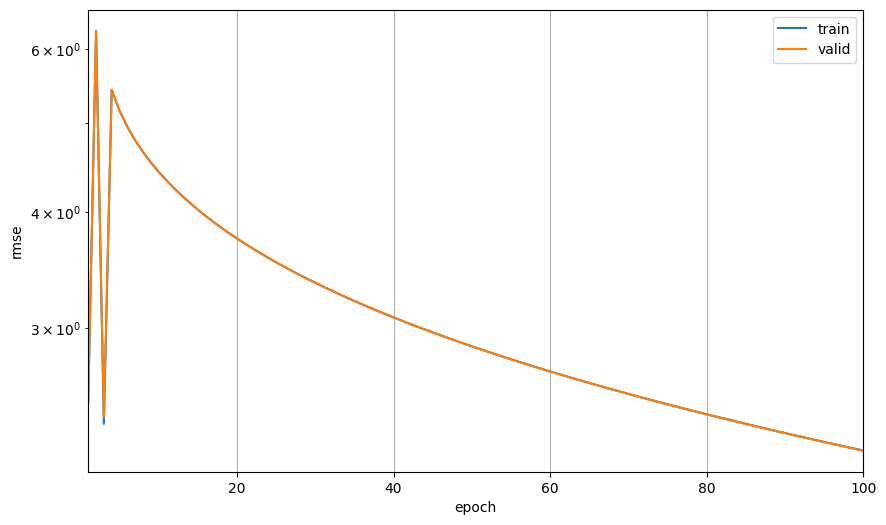

折1，训练log rmse2.210928, 验证log rmse2.209584
折2，训练log rmse1.585451, 验证log rmse1.587360
折3，训练log rmse1.250959, 验证log rmse1.260690
折4，训练log rmse1.048127, 验证log rmse1.047931
折5，训练log rmse0.921766, 验证log rmse0.912502
5-折交叉训练， 训练集平均损失为：1.403446， 验证集平均损失为：1.403613.


In [315]:
train_l, valid_l = kfold(net1, train_feature, train_label, n_split, epoch, batch_size, learningrate, weight_decay)
print(f'{n_split}-折交叉训练， 训练集平均损失为：{float(train_l):f}， 验证集平均损失为：{float(valid_l):f}.')